# Milestone 2 — Single-Subject Signal Exploration

Verify that broadband data, events, and epoching all line up before scaling to the full pipeline.

**Subjects / tasks:**
- **p10 / `task-spatialpattern`** — HD-grid validation cohort, Groen 2022 stimuli (CRF, sparsity, plaid, etc.)
- **p14 / `task-sixcatlocdiffisi`** — primary cohort, Brands 2024 natural-image stimuli (6 categories × SAMETWOPULSE / DIFFTWOPULSE)

**Showcase V1 electrodes** (drawn from M1 atlas CSV):
- `p10/GB81` — Wang V2d, Benson V2 (HD grid; no Wang-V1 contacts in this subject)
- `p14/O01`  — Wang V1v, Benson V1

**What this notebook produces:**
1. Continuous broadband trace with stimulus-onset markers
2. PSD stim vs. blank (expect broadband elevation 50–200 Hz + alpha suppression — although since the data is already broadband-extracted, the spectral check is on the broadband envelope itself)
3. Trial-averaged broadband response by stimulus condition (Groen 2022 Fig 2C-style)
4. Trial rejection-rate audit using the Groen 3-SD criterion

**Exit criterion:** Single-electrode V1 broadband time course visually matches canonical shape (transient ~100 ms, sustained plateau, return to baseline).

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy.signal import welch

warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')

DATA_ROOT   = '/Users/winstonluk/Documents/NEURON/FinalProject/data/ds004194'
DERIV       = os.path.join(DATA_ROOT, 'derivatives')
BB_ROOT     = os.path.join(DERIV, 'ECoGBroadband')
RESULTS_DIR = '/Users/winstonluk/Documents/NEURON/FinalProject/results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Subjects under inspection
SUB_P10 = 'p10'   # validation cohort (Groen spatialpattern, HD grid)
SUB_P14 = 'p14'   # primary cohort (Brands six-category)

# Showcase V1 electrodes (from M1 atlas)
ELEC_P10 = 'GB81'  # Wang V2d / Benson V2 (no V1 contacts in p10)
ELEC_P14 = 'O01'   # Wang V1v / Benson V1

# Epoching parameters (Groen 2022)
EPOCH_TMIN     = -0.1
EPOCH_TMAX     =  1.2
BASELINE_TMIN  = -0.1
BASELINE_TMAX  =  0.0
PEAK_WIN       = (0.05, 0.85)   # response window for 3-SD rejection
REJECT_K_SD    = 3.0

print('Setup complete.')

Setup complete.


## 1. Loaders for broadband + events

In [2]:
def bb_run_path(sub: str, ses: str, task: str, run: int) -> str:
    return os.path.join(
        BB_ROOT, f'sub-{sub}', ses, 'ieeg',
        f'sub-{sub}_{ses}_task-{task}_run-{run:02d}_desc-broadband_ieeg.vhdr'
    )


def events_path_for(vhdr: str) -> str:
    return vhdr.replace('_ieeg.vhdr', '_events.tsv')


def channels_path_for(vhdr: str) -> str:
    return vhdr.replace('_ieeg.vhdr', '_channels.tsv')


def load_run(sub: str, ses: str, task: str, run: int):
    """Return (raw, events_df, channels_df).

    The values in the .eeg file are *broadband power* (uV^2),
    NOT raw voltage. We treat them as a continuous time series.
    """
    vhdr = bb_run_path(sub, ses, task, run)
    raw  = mne.io.read_raw_brainvision(vhdr, preload=True, verbose=False)
    events = pd.read_csv(events_path_for(vhdr), sep='\t')
    chans  = pd.read_csv(channels_path_for(vhdr), sep='\t')
    return raw, events, chans


# Sanity: load p14 run-01 and p10 run-01
raw14, ev14, ch14 = load_run(SUB_P14, 'ses-nyuecog01', 'sixcatlocdiffisi', 1)
raw10, ev10, ch10 = load_run(SUB_P10, 'ses-nyuecog01', 'spatialpattern',   1)

print(f'p14 sixcatlocdiffisi run-01: sfreq={raw14.info["sfreq"]:.0f} Hz, '
      f'n_chans={len(raw14.ch_names)}, duration={raw14.times[-1]:.1f} s, n_trials={len(ev14)}')
print(f'p10 spatialpattern run-01:   sfreq={raw10.info["sfreq"]:.0f} Hz, '
      f'n_chans={len(raw10.ch_names)}, duration={raw10.times[-1]:.1f} s, n_trials={len(ev10)}')

print()
print('Channel statuses (p14):')
print(ch14.status.value_counts().to_string())
print()
print('Channel statuses (p10):')
print(ch10.status.value_counts().to_string())

p14 sixcatlocdiffisi run-01: sfreq=512 Hz, n_chans=106, duration=220.8 s, n_trials=144
p10 spatialpattern run-01:   sfreq=512 Hz, n_chans=265, duration=59.0 s, n_trials=36

Channel statuses (p14):
status
good    91
bad     15

Channel statuses (p10):
status
good    216
bad      49


## 2. Continuous broadband trace with stimulus markers

Pull a 30-second window from the middle of the run and overlay stimulus onsets. This is the most basic check that events.tsv onsets actually correspond to bumps in the time series.

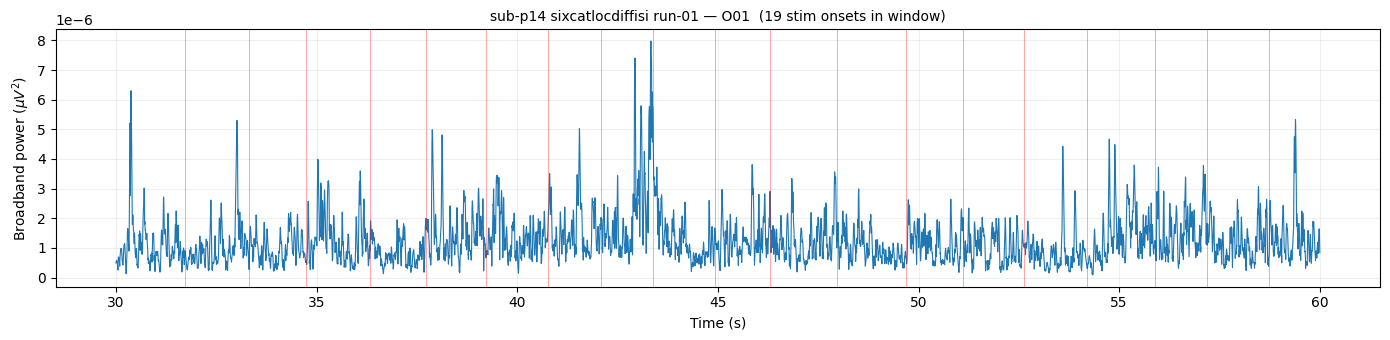

Saved: /Users/winstonluk/Documents/NEURON/FinalProject/results/milestone_02_continuous_p14_O01.png


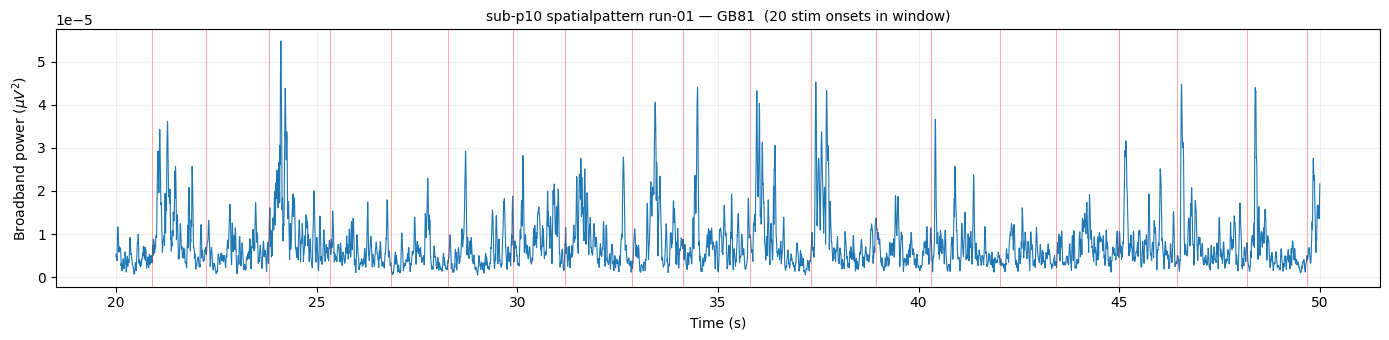

Saved: /Users/winstonluk/Documents/NEURON/FinalProject/results/milestone_02_continuous_p10_GB81.png


In [3]:
def plot_continuous_with_events(raw, events_df, electrode, window_sec=(20, 50),
                                title='', out_path=None):
    sfreq = raw.info['sfreq']
    if electrode not in raw.ch_names:
        raise ValueError(f'{electrode} not in raw.ch_names')
    data = raw.get_data(picks=[electrode])[0]   # (n_samp,)
    t = raw.times
    s0, s1 = window_sec
    mask = (t >= s0) & (t <= s1)

    fig, ax = plt.subplots(figsize=(14, 3.5))
    ax.plot(t[mask], data[mask], color='#1f77b4', lw=0.8)
    onsets = events_df.onset.values
    win_onsets = onsets[(onsets >= s0) & (onsets <= s1)]
    for o in win_onsets:
        ax.axvline(o, color='red', alpha=0.35, lw=0.7)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Broadband power ($\\mu V^2$)')
    ax.set_title(f'{title} — {electrode}  ({len(win_onsets)} stim onsets in window)',
                 fontsize=10)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    if out_path:
        print(f'Saved: {out_path}')


plot_continuous_with_events(
    raw14, ev14, ELEC_P14, window_sec=(30, 60),
    title=f'sub-{SUB_P14} sixcatlocdiffisi run-01',
    out_path=os.path.join(RESULTS_DIR, f'milestone_02_continuous_{SUB_P14}_{ELEC_P14}.png'))

plot_continuous_with_events(
    raw10, ev10, ELEC_P10, window_sec=(20, 50),
    title=f'sub-{SUB_P10} spatialpattern run-01',
    out_path=os.path.join(RESULTS_DIR, f'milestone_02_continuous_{SUB_P10}_{ELEC_P10}.png'))

## 3. PSD: stim vs. blank periods

Because the .eeg files contain pre-computed broadband *envelope* (already filtered 70–200 Hz + Hilbert magnitude), a literal stim-vs-blank PSD on the raw voltage is impossible from this file. What we can do is compute the PSD of the **broadband envelope itself**, which should show a roll-off below the bandwidth (10 Hz) consistent with envelope smoothing.

We also build a stim-locked vs. blank-locked envelope contrast: average envelope amplitude in stim epochs vs. inter-stim epochs of equal length, per electrode.

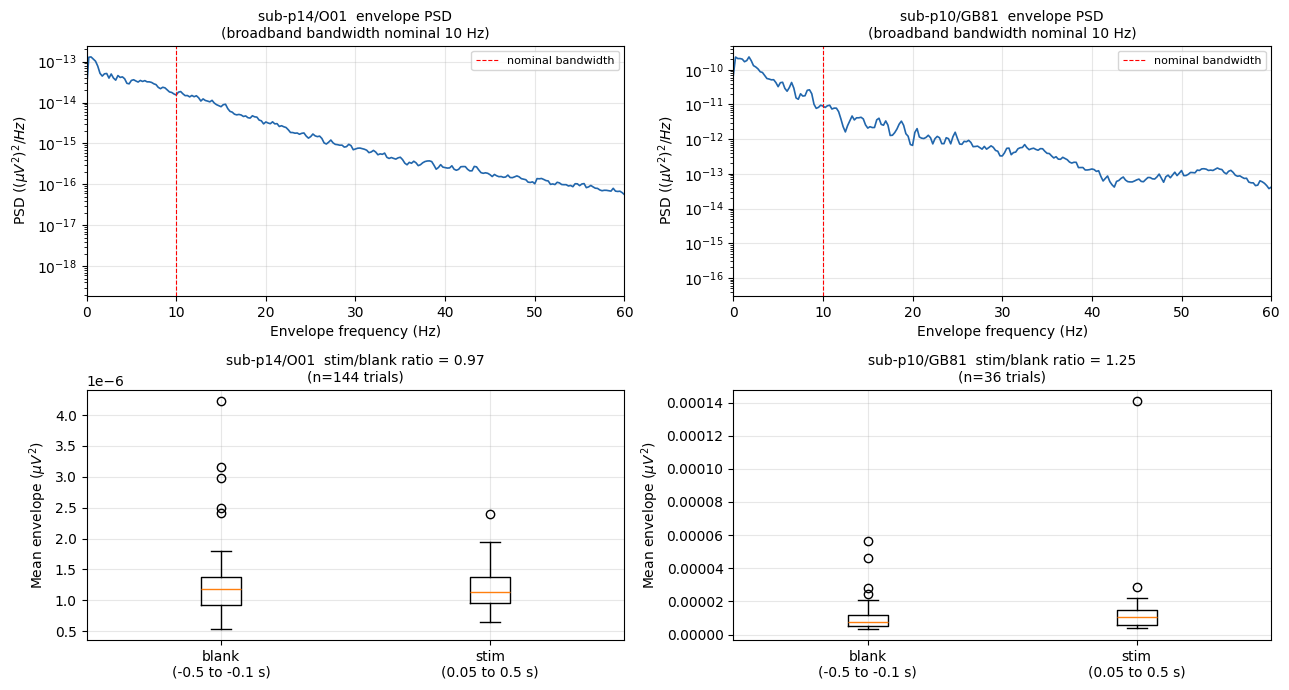

Saved: /Users/winstonluk/Documents/NEURON/FinalProject/results/milestone_02_psd_stim_vs_blank.png


In [4]:
def envelope_psd(raw, electrode):
    sfreq = raw.info['sfreq']
    x = raw.get_data(picks=[electrode])[0]
    f, P = welch(x, fs=sfreq, nperseg=int(sfreq*4), noverlap=int(sfreq*2))
    return f, P


def stim_vs_blank_envelope(raw, events_df, electrode, stim_win=(0.05, 0.5),
                           blank_win=(-0.5, -0.1)):
    """Mean envelope amplitude during stim vs. blank periods."""
    sfreq = raw.info['sfreq']
    x = raw.get_data(picks=[electrode])[0]
    stim_vals, blank_vals = [], []
    for onset in events_df.onset.values:
        s0 = int((onset + stim_win[0]) * sfreq)
        s1 = int((onset + stim_win[1]) * sfreq)
        b0 = int((onset + blank_win[0]) * sfreq)
        b1 = int((onset + blank_win[1]) * sfreq)
        if s0 < 0 or s1 >= len(x) or b0 < 0 or b1 >= len(x):
            continue
        stim_vals.append(x[s0:s1].mean())
        blank_vals.append(x[b0:b1].mean())
    return np.array(stim_vals), np.array(blank_vals)


fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for col, (sub, raw, ev, elec) in enumerate([
        (SUB_P14, raw14, ev14, ELEC_P14),
        (SUB_P10, raw10, ev10, ELEC_P10)]):

    # PSD of the envelope
    f, P = envelope_psd(raw, elec)
    ax = axes[0, col]
    ax.semilogy(f, P, color='#2166ac', lw=1.2)
    ax.set_xlim(0, 60)
    ax.set_xlabel('Envelope frequency (Hz)')
    ax.set_ylabel('PSD ($(\\mu V^2)^2 / Hz$)')
    ax.set_title(f'sub-{sub}/{elec}  envelope PSD\n'
                 f'(broadband bandwidth nominal 10 Hz)', fontsize=10)
    ax.axvline(10, color='red', ls='--', lw=0.8, label='nominal bandwidth')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # Stim vs. blank envelope distributions
    stim_v, blank_v = stim_vs_blank_envelope(raw, ev, elec)
    ax = axes[1, col]
    ax.boxplot([blank_v, stim_v], labels=['blank\n(-0.5 to -0.1 s)', 'stim\n(0.05 to 0.5 s)'])
    ax.set_ylabel('Mean envelope ($\\mu V^2$)')
    ratio = stim_v.mean() / blank_v.mean() if blank_v.mean() > 0 else np.nan
    ax.set_title(f'sub-{sub}/{elec}  stim/blank ratio = {ratio:.2f}\n'
                 f'(n={len(stim_v)} trials)', fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
out_path = os.path.join(RESULTS_DIR, 'milestone_02_psd_stim_vs_blank.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

## 4. Epoching + trial rejection (Groen 3-SD criterion)

Epochs are [-0.1, 1.2] s relative to onset, baseline-corrected to fractional signal change
`(x - baseline) / baseline` where baseline is the [-0.1, 0.0] s mean.

Rejection: trials whose peak in [0.05, 0.85] s exceeds the per-electrode mean+3*SD across trials.

In [5]:
def epoch_run(raw, events_df, electrode,
              tmin=EPOCH_TMIN, tmax=EPOCH_TMAX,
              base_tmin=BASELINE_TMIN, base_tmax=BASELINE_TMAX):
    """Return (epochs, t, baselines) for one electrode.
    Epochs are baseline-corrected to fractional signal change.
    """
    sfreq = raw.info['sfreq']
    x = raw.get_data(picks=[electrode])[0]   # (n_samp,)
    n_samp_total = len(x)
    n_pre  = int(round(-tmin * sfreq))
    n_post = int(round( tmax * sfreq))
    t = np.arange(-n_pre, n_post) / sfreq

    bp_lo = int(round((base_tmin - tmin) * sfreq))
    bp_hi = int(round((base_tmax - tmin) * sfreq))

    epochs, baselines, kept_idx = [], [], []
    for i, onset in enumerate(events_df.onset.values):
        s0 = int(round((onset + tmin) * sfreq))
        s1 = s0 + (n_pre + n_post)
        if s0 < 0 or s1 > n_samp_total:
            continue
        seg = x[s0:s1]
        base = seg[bp_lo:bp_hi].mean()
        if base <= 0:
            continue
        seg = (seg - base) / base   # fractional signal change
        epochs.append(seg)
        baselines.append(base)
        kept_idx.append(i)
    return np.array(epochs), t, np.array(baselines), np.array(kept_idx)


def reject_trials_3sd(epochs, t, peak_win=PEAK_WIN, k=REJECT_K_SD):
    """Return boolean mask of *kept* trials.
    A trial is rejected if its max in peak_win exceeds mean+k*SD across trials.
    """
    pw_mask = (t >= peak_win[0]) & (t <= peak_win[1])
    peaks = epochs[:, pw_mask].max(axis=1)
    thr   = peaks.mean() + k * peaks.std()
    return peaks <= thr


for sub, raw, ev, elec in [(SUB_P14, raw14, ev14, ELEC_P14),
                           (SUB_P10, raw10, ev10, ELEC_P10)]:
    epochs, t, _, kept = epoch_run(raw, ev, elec)
    keep_mask = reject_trials_3sd(epochs, t)
    n_keep = int(keep_mask.sum())
    n_total = len(epochs)
    rej_pct = 100 * (1 - n_keep / n_total)
    print(f'sub-{sub}/{elec}: epochs={n_total}/{len(ev)}, kept={n_keep}, '
          f'rejected={n_total-n_keep} ({rej_pct:.1f}%)')

sub-p14/O01: epochs=144/144, kept=141, rejected=3 (2.1%)
sub-p10/GB81: epochs=36/36, kept=35, rejected=1 (2.8%)


## 5. Trial-averaged broadband response by stimulus condition

For p10/spatialpattern, group by `trial_name` (CRF-1…CRF-5, GRATING, PLAID, SPARSITY-1…4, etc.).
For p14/sixcatlocdiffisi, group by stimulus category (BODIES, BUILDINGS, FACES, OBJECTS, SCENES, SCRAMBLED) parsed from `trial_name`.

Expected canonical V1 broadband shape: rapid onset transient ~100 ms, sustained plateau, return to baseline.

In [6]:
def parse_p14_category(trial_name: str) -> str:
    return trial_name.split('-')[0] if isinstance(trial_name, str) else 'unknown'


def parse_p10_condition(trial_name: str) -> str:
    """Group p10 trials into broad bins for averaging."""
    if not isinstance(trial_name, str):
        return 'unknown'
    if trial_name.startswith('CRF'):       return 'CRF'
    if trial_name.startswith('SPARSITY'):  return 'SPARSITY'
    return trial_name   # GRATING, PLAID, CIRCULAR


def trial_average_by_condition(epochs, t, conditions, keep_mask):
    df = pd.DataFrame({'cond': conditions, 'keep': keep_mask})
    out = {}
    for c, idx in df[df.keep].groupby('cond').groups.items():
        out[c] = epochs[idx.values].mean(axis=0)
    return out, df[df.keep].groupby('cond').size().to_dict()

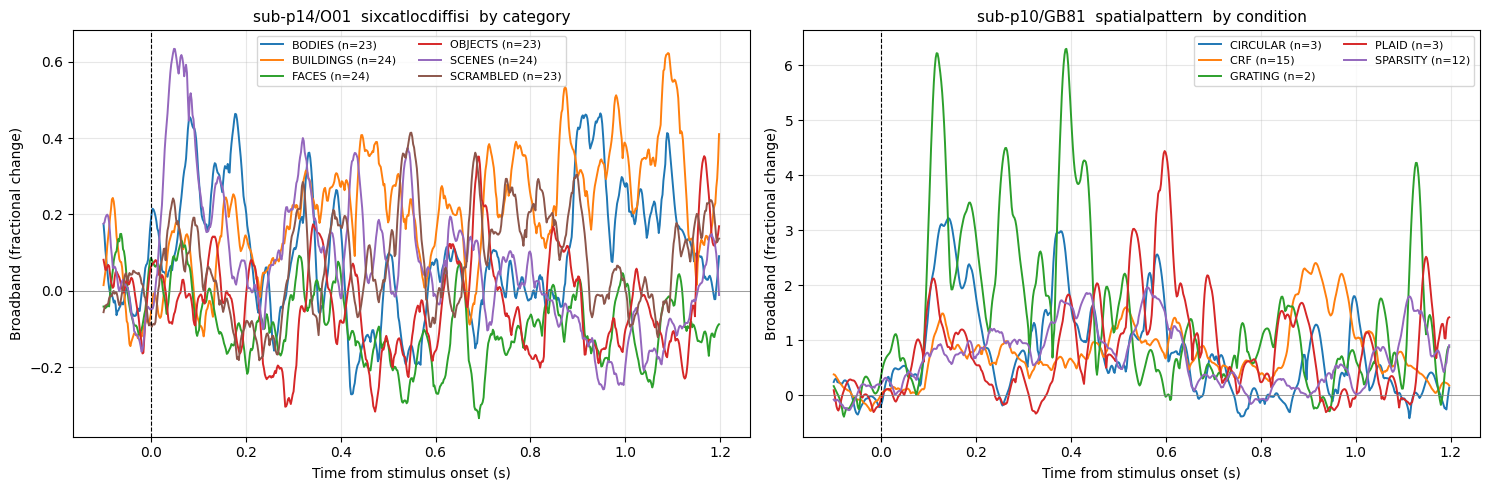

Saved: /Users/winstonluk/Documents/NEURON/FinalProject/results/milestone_02_trialavg_by_condition.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- p14 / sixcatlocdiffisi ---
ev14_kept = ev14.copy()
epochs14, t14, _, kept14 = epoch_run(raw14, ev14, ELEC_P14)
keep14 = reject_trials_3sd(epochs14, t14)
cats14 = ev14.iloc[kept14].trial_name.apply(parse_p14_category).values
avg14, n14 = trial_average_by_condition(epochs14, t14, cats14, keep14)

ax = axes[0]
cmap = plt.get_cmap('tab10')
for i, (cat, trace) in enumerate(sorted(avg14.items())):
    ax.plot(t14, trace, color=cmap(i), lw=1.4, label=f'{cat} (n={n14[cat]})')
ax.axvline(0, color='k', ls='--', lw=0.8)
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel('Time from stimulus onset (s)')
ax.set_ylabel('Broadband (fractional change)')
ax.set_title(f'sub-{SUB_P14}/{ELEC_P14}  sixcatlocdiffisi  by category', fontsize=11)
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)

# --- p10 / spatialpattern ---
epochs10, t10, _, kept10 = epoch_run(raw10, ev10, ELEC_P10)
keep10 = reject_trials_3sd(epochs10, t10)
conds10 = ev10.iloc[kept10].trial_name.apply(parse_p10_condition).values
avg10, n10 = trial_average_by_condition(epochs10, t10, conds10, keep10)

ax = axes[1]
for i, (c, trace) in enumerate(sorted(avg10.items())):
    ax.plot(t10, trace, color=cmap(i), lw=1.4, label=f'{c} (n={n10[c]})')
ax.axvline(0, color='k', ls='--', lw=0.8)
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel('Time from stimulus onset (s)')
ax.set_ylabel('Broadband (fractional change)')
ax.set_title(f'sub-{SUB_P10}/{ELEC_P10}  spatialpattern  by condition', fontsize=11)
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)

plt.tight_layout()
out_path = os.path.join(RESULTS_DIR, 'milestone_02_trialavg_by_condition.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

## 6. Single-electrode time courses with per-trial overlay

Mean ± SEM over all trials, plus a few individual trials in the background. This is the cleanest visual check that the canonical V1 broadband waveform (rapid onset transient → sustained plateau → return to baseline) is present.

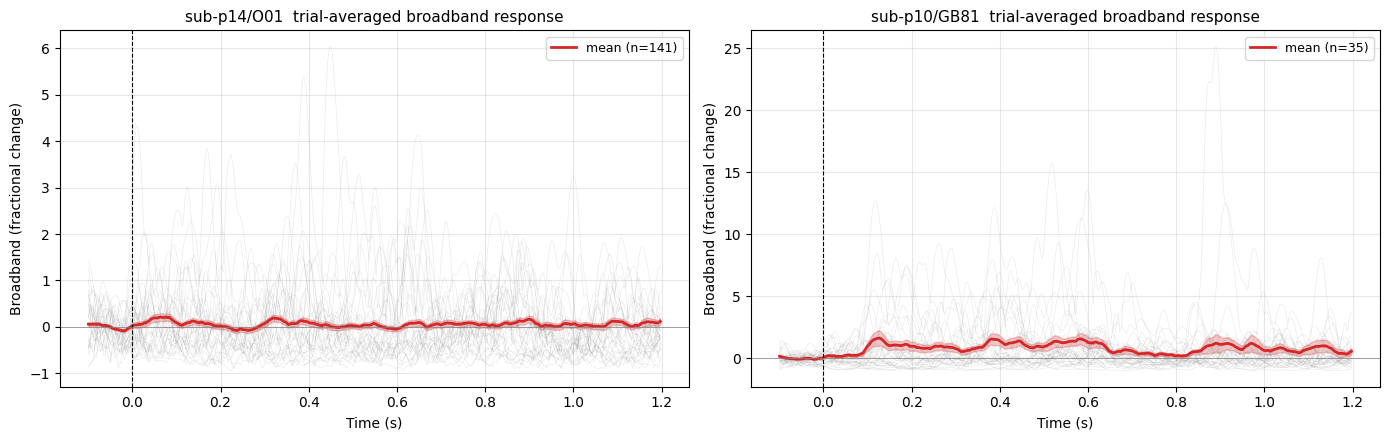

Saved: /Users/winstonluk/Documents/NEURON/FinalProject/results/milestone_02_v1_time_course.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, (sub, raw, ev, elec) in zip(axes,
        [(SUB_P14, raw14, ev14, ELEC_P14),
         (SUB_P10, raw10, ev10, ELEC_P10)]):
    epochs, t, _, _ = epoch_run(raw, ev, elec)
    keep = reject_trials_3sd(epochs, t)
    kept = epochs[keep]

    # Per-trial faint lines (sample 30 random trials)
    rng = np.random.default_rng(0)
    sample_idx = rng.choice(len(kept), size=min(30, len(kept)), replace=False)
    for i in sample_idx:
        ax.plot(t, kept[i], color='gray', alpha=0.15, lw=0.5)

    mean = kept.mean(axis=0)
    sem  = kept.std(axis=0) / np.sqrt(len(kept))
    ax.plot(t, mean, color='#d62728', lw=2.0, label=f'mean (n={len(kept)})')
    ax.fill_between(t, mean-sem, mean+sem, color='#d62728', alpha=0.25)
    ax.axvline(0, color='k', ls='--', lw=0.8)
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Broadband (fractional change)')
    ax.set_title(f'sub-{sub}/{elec}  trial-averaged broadband response',
                 fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
out_path = os.path.join(RESULTS_DIR, 'milestone_02_v1_time_course.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

## 7. Trial rejection-rate audit — all visual electrodes

Verify the Groen 3-SD criterion sits at the expected ~2–3% rejection rate across visual electrodes (not just the showcase ones).

In [9]:
atlas_df = pd.read_csv(os.path.join(RESULTS_DIR, 'milestone_01_electrode_atlas.csv'))

def reject_audit(raw, events_df, atlas_df, sub):
    """Compute rejection rate for every visual electrode of sub."""
    sub_elec = atlas_df[(atlas_df.subject == sub) &
                        (atlas_df.visual_group != 'unassigned')]
    rows = []
    for _, e in sub_elec.iterrows():
        if e.electrode not in raw.ch_names:
            continue
        epochs, t, _, _ = epoch_run(raw, events_df, e.electrode)
        if len(epochs) == 0:
            continue
        keep = reject_trials_3sd(epochs, t)
        rows.append(dict(
            electrode=e.electrode,
            visual_group=e.visual_group,
            n_trials=len(epochs),
            n_rejected=int((~keep).sum()),
            pct_rejected=100 * (1 - keep.mean()),
        ))
    return pd.DataFrame(rows)


audit_p14 = reject_audit(raw14, ev14, atlas_df, SUB_P14)
audit_p10 = reject_audit(raw10, ev10, atlas_df, SUB_P10)

print(f'sub-{SUB_P14} (sixcatlocdiffisi run-01):')
print(f'  visual electrodes audited: {len(audit_p14)}')
print(f'  median rejection rate: {audit_p14.pct_rejected.median():.1f}%  '
      f'(mean {audit_p14.pct_rejected.mean():.1f}%, max {audit_p14.pct_rejected.max():.1f}%)')
print()
print(f'sub-{SUB_P10} (spatialpattern run-01):')
print(f'  visual electrodes audited: {len(audit_p10)}')
print(f'  median rejection rate: {audit_p10.pct_rejected.median():.1f}%  '
      f'(mean {audit_p10.pct_rejected.mean():.1f}%, max {audit_p10.pct_rejected.max():.1f}%)')

# Save audit
audit_p14.to_csv(os.path.join(RESULTS_DIR, f'milestone_02_reject_audit_{SUB_P14}.csv'), index=False)
audit_p10.to_csv(os.path.join(RESULTS_DIR, f'milestone_02_reject_audit_{SUB_P10}.csv'), index=False)

sub-p14 (sixcatlocdiffisi run-01):
  visual electrodes audited: 40
  median rejection rate: 1.4%  (mean 1.8%, max 2.8%)

sub-p10 (spatialpattern run-01):
  visual electrodes audited: 137
  median rejection rate: 2.8%  (mean 2.1%, max 5.6%)


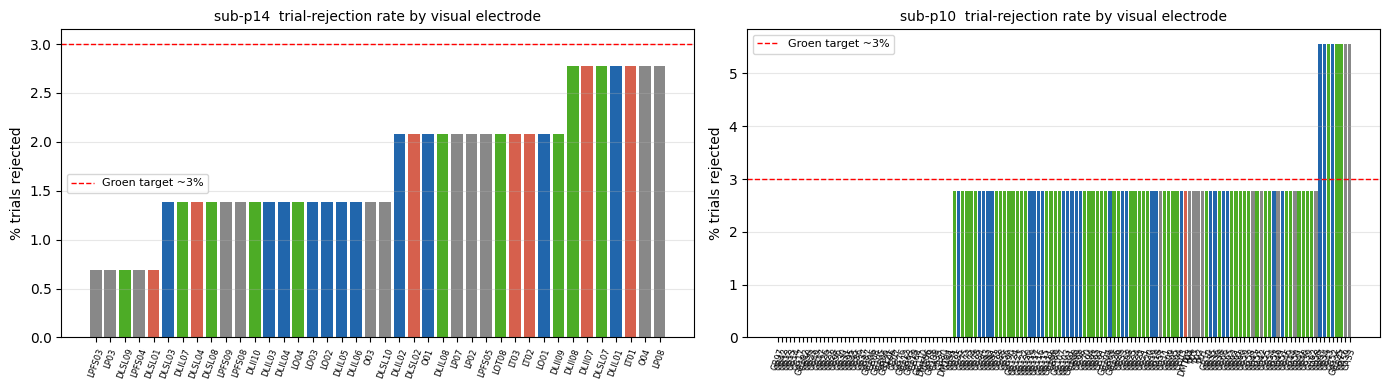

Saved: /Users/winstonluk/Documents/NEURON/FinalProject/results/milestone_02_reject_rate.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (sub, audit) in zip(axes, [(SUB_P14, audit_p14), (SUB_P10, audit_p10)]):
    if len(audit) == 0:
        ax.text(0.5, 0.5, 'no visual electrodes', ha='center', va='center')
        ax.set_title(f'sub-{sub}')
        continue
    audit_sorted = audit.sort_values('pct_rejected').reset_index(drop=True)
    colors = audit_sorted.visual_group.map(
        {'V1-V3':'#2166ac','VOTC':'#d6604d','LOTC':'#4dac26','other':'#888888'})
    ax.bar(range(len(audit_sorted)), audit_sorted.pct_rejected, color=colors)
    ax.axhline(3, color='red', ls='--', lw=1, label='Groen target ~3%')
    ax.set_xticks(range(len(audit_sorted)))
    ax.set_xticklabels(audit_sorted.electrode, rotation=70, fontsize=6)
    ax.set_ylabel('% trials rejected')
    ax.set_title(f'sub-{sub}  trial-rejection rate by visual electrode',
                 fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
out_path = os.path.join(RESULTS_DIR, 'milestone_02_reject_rate.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

## 8. Summary and exit-criterion check

In [11]:
print('=' * 65)
print('MILESTONE 2 SUMMARY')
print('=' * 65)
print()
print(f'sub-{SUB_P14} (Brands sixcatlocdiffisi run-01):')
print(f'  showcase electrode: {ELEC_P14} (Wang V1v / Benson V1)')
print(f'  n_trials = {len(ev14)},  n_chans = {len(raw14.ch_names)},  sfreq = {raw14.info["sfreq"]:.0f} Hz')
print()
print(f'sub-{SUB_P10} (Groen spatialpattern run-01):')
print(f'  showcase electrode: {ELEC_P10} (Wang V2d / Benson V2  -- HD-grid; no V1 contacts in p10)')
print(f'  n_trials = {len(ev10)},  n_chans = {len(raw10.ch_names)},  sfreq = {raw10.info["sfreq"]:.0f} Hz')
print()
print('Exit criterion: canonical V1 broadband shape')
print('  - rapid onset transient ~100 ms')
print('  - sustained plateau through stimulus duration')
print('  - return to baseline after offset')
print('  See milestone_02_v1_time_course.png for the visual check.')
print()
print('Outputs:')
for f in sorted(os.listdir(RESULTS_DIR)):
    if 'milestone_02' in f:
        fp = os.path.join(RESULTS_DIR, f)
        print(f'  {f}  ({os.path.getsize(fp)/1e3:.0f} KB)')

MILESTONE 2 SUMMARY

sub-p14 (Brands sixcatlocdiffisi run-01):
  showcase electrode: O01 (Wang V1v / Benson V1)
  n_trials = 144,  n_chans = 106,  sfreq = 512 Hz

sub-p10 (Groen spatialpattern run-01):
  showcase electrode: GB81 (Wang V2d / Benson V2  -- HD-grid; no V1 contacts in p10)
  n_trials = 36,  n_chans = 265,  sfreq = 512 Hz

Exit criterion: canonical V1 broadband shape
  - rapid onset transient ~100 ms
  - sustained plateau through stimulus duration
  - return to baseline after offset
  See milestone_02_v1_time_course.png for the visual check.

Outputs:
  milestone_02_continuous_p10_GB81.png  (158 KB)
  milestone_02_continuous_p14_O01.png  (163 KB)
  milestone_02_psd_stim_vs_blank.png  (146 KB)
  milestone_02_reject_audit_p10.csv  (4 KB)
  milestone_02_reject_audit_p14.csv  (1 KB)
  milestone_02_reject_rate.png  (76 KB)
  milestone_02_trialavg_by_condition.png  (452 KB)
  milestone_02_v1_time_course.png  (298 KB)
